El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales simple, con un total de 6 capas.

Importación de librerías

In [2]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [3]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [4]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [5]:
# Directorio original y reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'


# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)

# Se llama a la función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida


Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación del modelo

In [6]:
semilla = 42
tf.random.set_seed(semilla)

model1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model1.summary()

# Entrenamiento 15 épocas, batch size 8, early stopping
print("Iniciando entrenamiento")

# Guardar el mejor modelo según la métrica seleccionada
checkpoint = ModelCheckpoint(
    filepath="mejor_modelo.h5",       # Nombre del archivo de salida
    monitor="loss",                   # Métrica a monitorear ("loss" o "val_loss")
    save_best_only=True,              # Guarda solo el mejor modelo
    save_weights_only=False,          # Guarda modelo completo (estructura + pesos + optimizer)
    mode="min",                       # "min" porque queremos minimizar la loss
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history1 = model1.fit(
    X, y,
    epochs=15,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history1.history['loss'][-1]:.4f}")

Resumen del modelo:


c:\Users\jhona\python1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 64s 692ms/step - loss: 0.0076 - mean_absolute_percentage_error: 1321.7526 - root_mean_squared_error: 0.0872
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - loss: 0.0076 - mean_absolute_percentage_error: 1228.2651 - root_mean_squared_error: 0.0870
Epoch 5: loss improved from 0.00760 to 0.00750, saving model to mejor_modelo.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 65s 704ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1301.9257 - root_mean_squared_error: 0.0866
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1215.0784 - root_mean_squared_error: 0.0868
Epoch 6: loss improved from 0.00750 to 0.00748, saving model to mejor_modelo.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 65s 701ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1291.0903 - root_mean_squared_error: 0.0865
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1205.5756 - root_mean_squared_error: 0.0866
Epoch 7: loss improved from 0.00748 to 0.00747, saving model to mejor_modelo.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 66s 704ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1283.4358 - root_mean_squared_error: 0.0864
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1198.0493 - root_mean_squared_error: 0.0865
Epoch 8: loss improved from 0.00747 to 0.00746, saving model to mejor_modelo.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 67s 716ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1275.9359 - root_mean_squared_error: 0.0864
Epoch 9/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1190.2672 - root_mean_squared_error: 0.0865
Epoch 9: loss did not improve from 0.00746
93/93 ━━━━━━━━━━━━━━━━━━━━ 66s 715ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1269.9988 - root_mean_squared_error: 0.0864
Epoch 10/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1183.9066 - root_mean_squared_error: 0.0867
Epoch 10: loss did not improve from 0.00746
93/93 ━━━━━━━━━━━━━━━━━━━━ 68s 732ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1265.2737 - root_mean_squared_error: 0.0865
Epoch 11/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - loss: 0.0075 - mean_absolute_percentage_error: 1180.5460 - root_mean_squared_error: 0.0868
Epoch 11: loss did not improve from 0.00746
93/93 ━━━━━━━━━━━━━━━━━━━━ 

Valores de las metricas

In [7]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado sin compilar (para evitar problemas de deserialización de métricas)
mejor_modelo = load_model("mejor_modelo.h5", compile=False)

# Recompilar el modelo con las métricas correctas
mejor_modelo.compile(
	optimizer="adam",
	loss="mse",
	metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError()]
)

print("Mejor modelo cargado correctamente")
mejor_modelo.summary()

# Evaluación en los mismos datos de entrenamiento (o validación si tienes)
loss, rmse, mape = mejor_modelo.evaluate(X, y, verbose=1)
print(f"Resultados del mejor modelo:")
print(f" - Loss (MSE): {loss:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - MAPE: {mape:.2f}%")

# Predicciones con el mejor modelo
y_pred_best = mejor_modelo.predict(X)

# Ejemplo: mostrar primeras 5 predicciones
print("Ejemplo de predicciones (primeros 5):")
print(y_pred_best[:5])

Mejor modelo cargado correctamente


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

 Trainable params: 46,529 (181.75 KB)

 Non-trainable params: 0 (0.00 B)

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 442ms/step - loss: 0.0074 - mean_absolute_percentage_error: 1304.6477 - root_mean_squared_error: 0.0861
Resultados del mejor modelo:
 - Loss (MSE): 0.0074
 - RMSE: 0.0861
 - MAPE: 1304.65%
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step
Ejemplo de predicciones (primeros 5):
[[[[0.45657492]
   [0.64756334]
   [0.92083335]
   ...
   [0.9552169 ]
   [0.87931484]
   [0.7751095 ]]

  [[0.74859047]
   [0.8781689 ]
   [1.026838  ]
   ...
   [0.9339165 ]
   [0.89103025]
   [0.79620135]]

  [[0.90347326]
   [0.90611136]
   [0.98016655]
   ...
   [0.859439  ]
   [0.85690904]
   [0.8603011 ]]

  ...

  [[0.74121237]
   [0.7607683 ]
   [0.74945724]
   ...
   [0.5597899 ]
   [0.5622404 ]
   [0.569162  ]]

  [[0.71331626]
   [0.755175  ]
   [0.7484538 ]
   ...
   [0.5026909 ]
   [0.5170066 ]
   [0.48682085]]

  [[0.63374174]
   [0.7532594 ]
   [0.68631345]
   ...
   [0.43704683]
   [0.40672743]
   [0.30528024]]]


 [[[0.46111733]
   [0.6552734 ]
   [0.9297424 ]
   ...
   [0.

In [8]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model1.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step - loss: 0.0074 - mean_absolute_percentage_error: 1304.6477 - root_mean_squared_error: 0.0861
Pérdida (MSE): 0.0074
RMSE: 0.0861
MAPE: 1304.6477


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 477ms/step


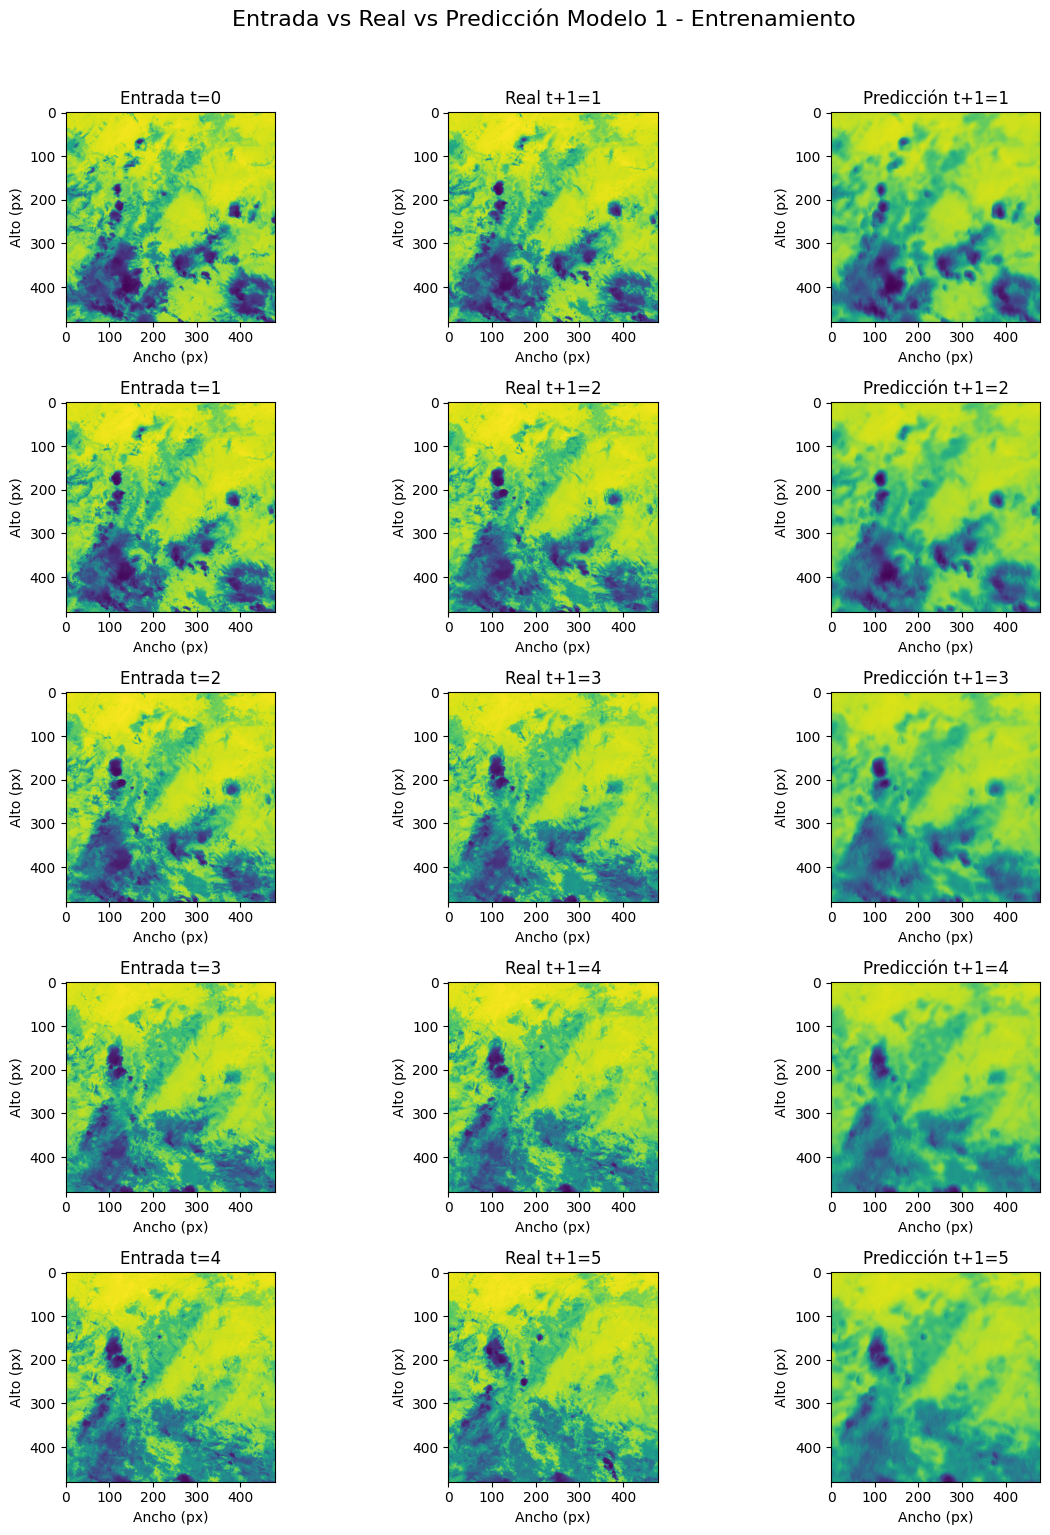

In [9]:
y_pred1 = model1.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred1, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 530ms/step


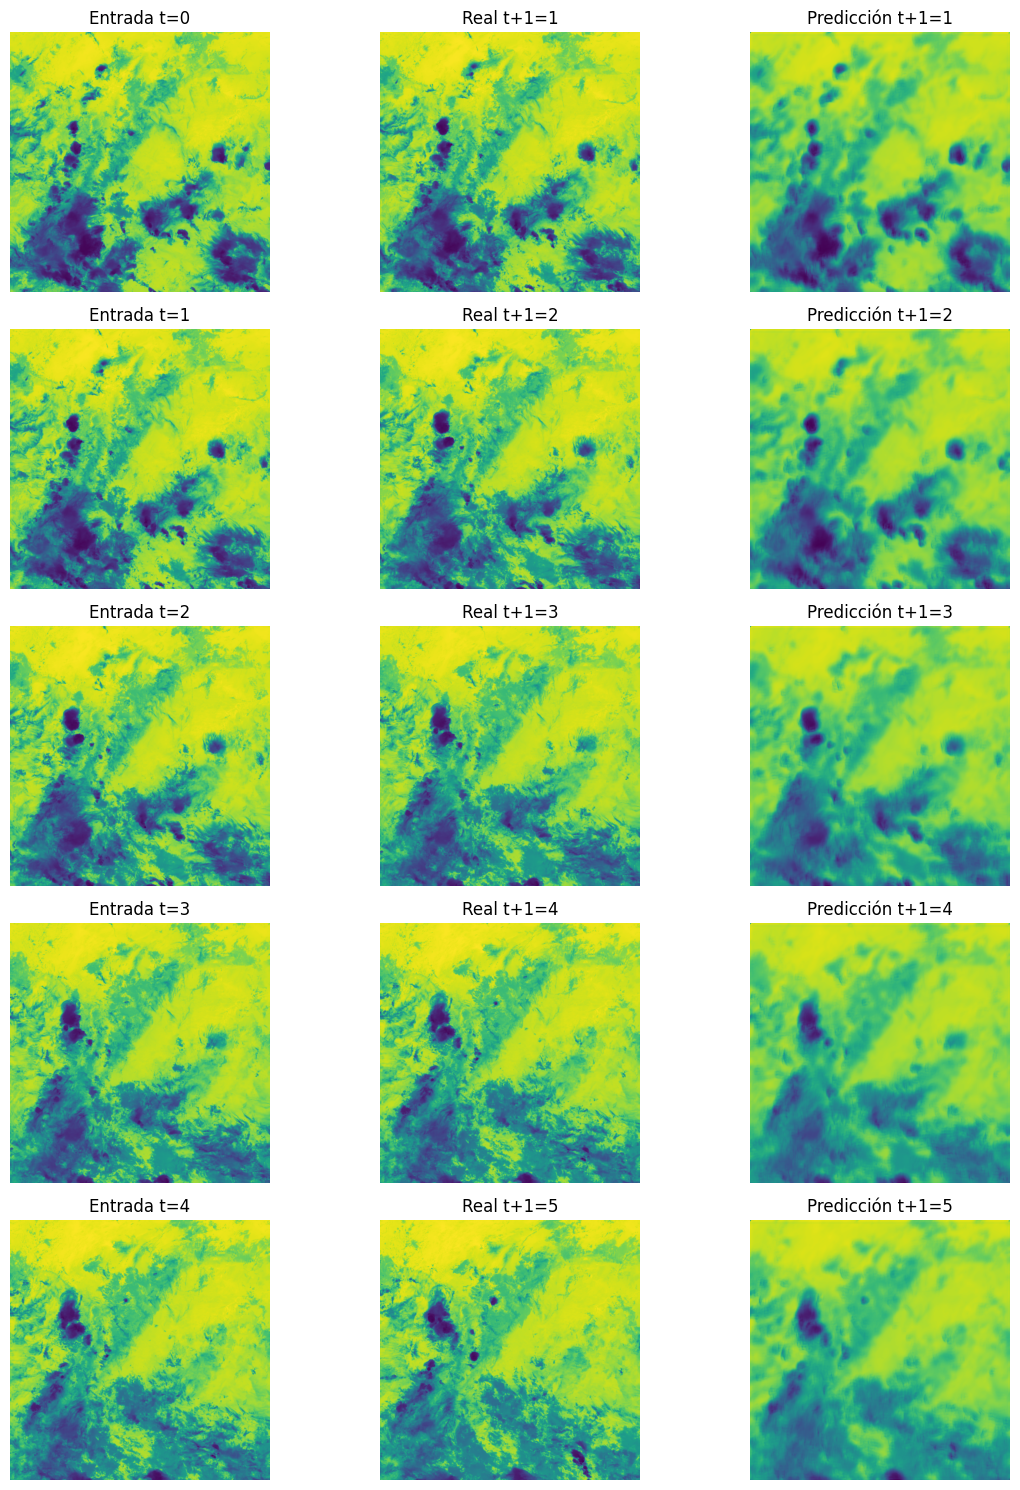

In [10]:
y_pred1 = model1.predict(X)  # Genera las predicciones

# Selecciona el número de ejemplos a mostrar
n = 5

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred1[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

Validación

In [11]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [12]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model1.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - loss: 0.0162 - mean_absolute_percentage_error: 1161.5471 - root_mean_squared_error: 0.1274
Pérdida (MSE): 0.0162
RMSE: 0.1274
MAPE: 1161.5471


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step


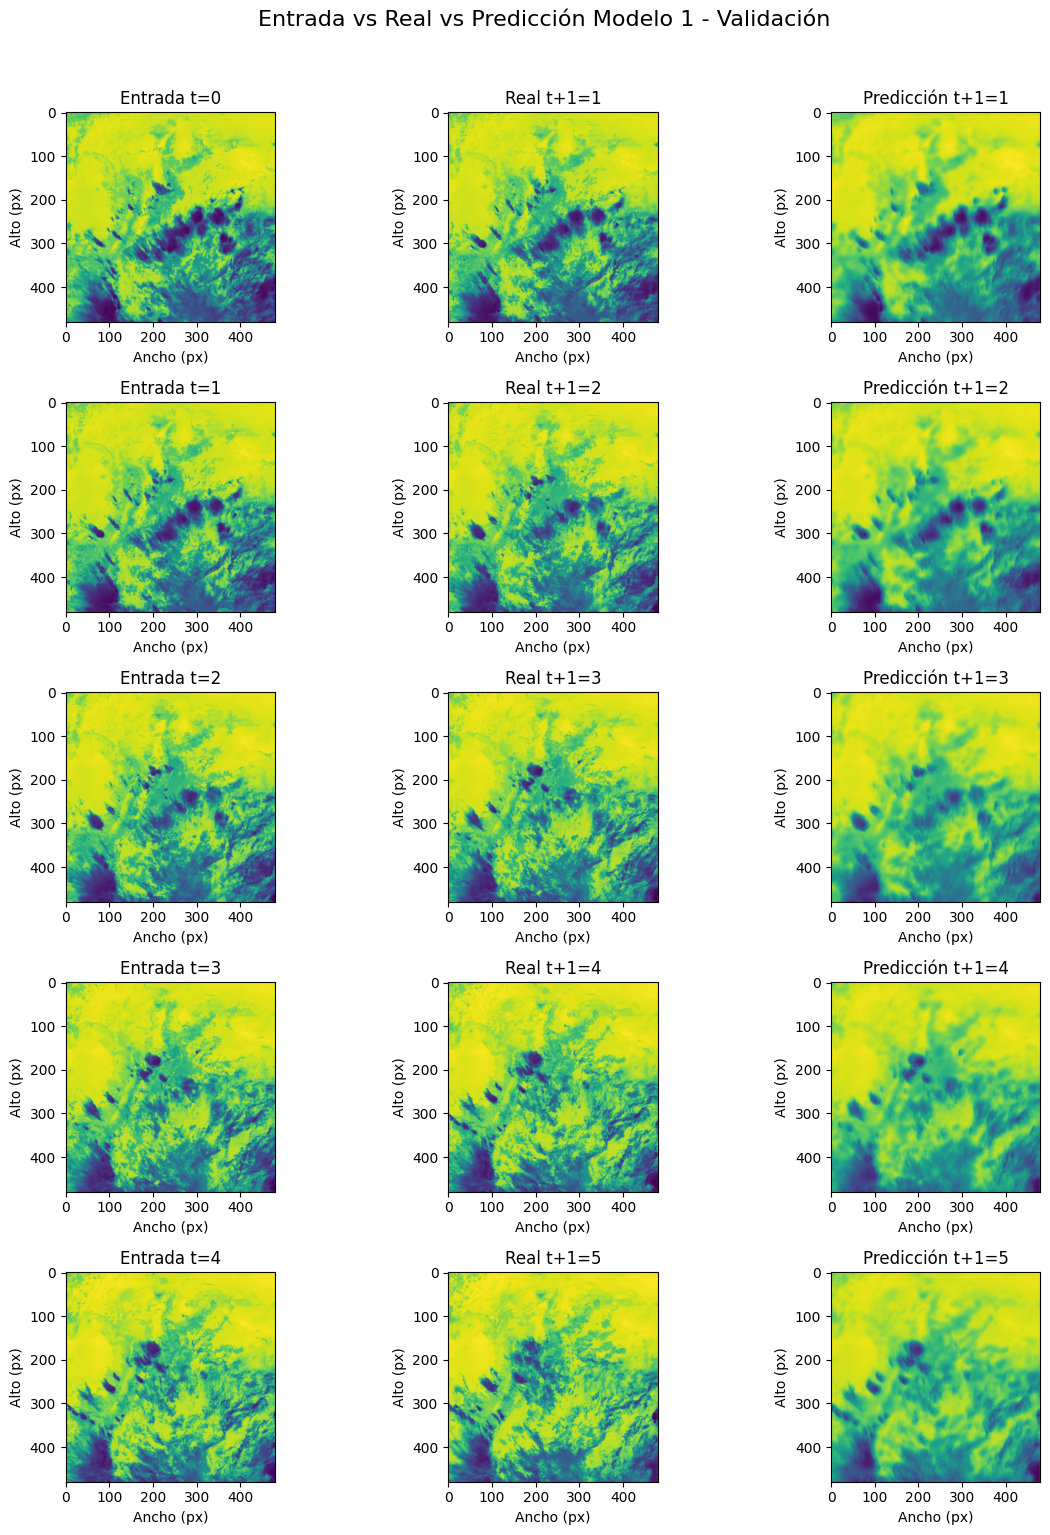

In [13]:
y_pred1_val = model1.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred1_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)